# LoanShield: Logistic Regression From Scratch
In this notebook, we implement **Logistic Regression** manually using NumPy, without using scikit-learn's `LogisticRegression` class.

**Objective:** Understand the mathematics behind the model (Sigmoid, Gradient Descent, Loss Function).

**Math Refresher:**
1. **Sigmoid Function:** Maps any real value to a probability between 0 and 1.
   $$\sigma(z) = \frac{1}{1 + e^{-z}}$$
2. **Prediction:** $\hat{y} = \sigma(X \cdot w + b)$
3. **Cost Function (Binary Cross Entropy):**
   $$J(w,b) = - \frac{1}{m} \sum [y \log(\hat{y}) + (1-y) \log(1-\hat{y})]$$
4. **Gradient Descent:** Update weights to minimize the cost.

In [1]:
# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
sns.set_style("whitegrid")

In [2]:
# 2. Load Processed Data
# We load the data we prepared in Week 2
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.flatten() # Flatten to 1D array
y_test = pd.read_csv('../data/processed/y_test.csv').values.flatten()

print(f"Train Shape: {X_train.shape}")
print(f"Test Shape: {X_test.shape}")

Train Shape: (204277, 22)
Test Shape: (51070, 22)


## Part 1: Implementing the Class
We will create a class `LogisticRegressionScratch` with methods:
- `sigmoid`: The activation function.
- `fit`: To train the model using Gradient Descent.
- `predict_proba`: To return probabilities.
- `predict`: To return 0 or 1 labels.

In [3]:
class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def sigmoid(self, z):
        # Clip z to avoid overflow errors with exp
        z = np.clip(z, -250, 250)
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        # Initialize parameters
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Gradient Descent Loop
        for i in range(self.n_iterations):
            # 1. Linear model: z = w*x + b
            linear_model = np.dot(X, self.weights) + self.bias
            
            # 2. Activation (Sigmoid)
            y_predicted = self.sigmoid(linear_model)

            # 3. Compute Gradients
            # derivative wrt weights: (1/m) * X.T * (y_pred - y)
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            # derivative wrt bias: (1/m) * sum(y_pred - y)
            db = (1 / n_samples) * np.sum(y_predicted - y)

            # 4. Update Parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # 5. Track Loss (Log Loss) for visualization
            # Add small epsilon to avoid log(0) error
            epsilon = 1e-15
            y_pred_clipped = np.clip(y_predicted, epsilon, 1 - epsilon)
            loss = - (1/n_samples) * np.sum(y * np.log(y_pred_clipped) + (1 - y) * np.log(1 - y_pred_clipped))
            self.loss_history.append(loss)
            
            # Print progress every 100 iterations
            if i % 100 == 0:
                print(f"Iteration {i}: Loss {loss:.4f}")

    def predict_proba(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return self.sigmoid(linear_model)

    def predict(self, X, threshold=0.5):
        y_predicted_cls = [1 if i > threshold else 0 for i in self.predict_proba(X)]
        return np.array(y_predicted_cls)

## Part 2: Training the Model
We will train our custom model with:
- **Learning Rate:** 0.1 (Step size for updates)
- **Iterations:** 1000 (How many times to loop through data)

In [4]:
# Initialize and Train
model = LogisticRegressionScratch(learning_rate=0.1, n_iterations=1000)

print("Starting Training...")
model.fit(X_train, y_train)
print("Training Complete.")

Starting Training...
Iteration 0: Loss 0.6931
Iteration 100: Loss 0.3347
Iteration 200: Loss 0.3250
Iteration 300: Loss 0.3221
Iteration 400: Loss 0.3208
Iteration 500: Loss 0.3202
Iteration 600: Loss 0.3197
Iteration 700: Loss 0.3194
Iteration 800: Loss 0.3191
Iteration 900: Loss 0.3189
Training Complete.


## Part 3: Evaluation
Let's visualize how the Loss decreased over time and check the accuracy.

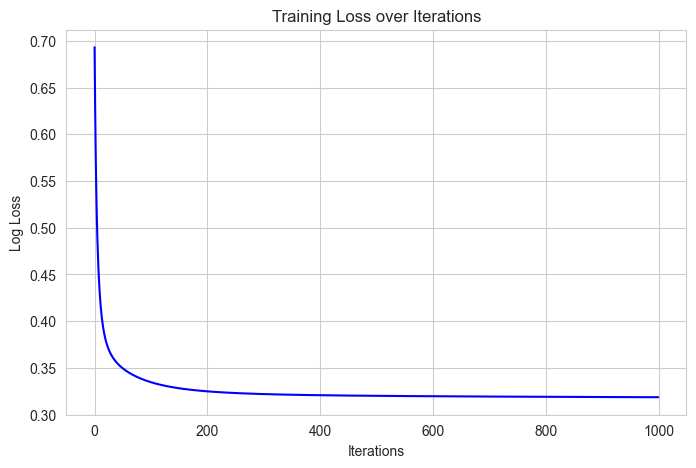

Test Accuracy: 88.48%


In [5]:
# 1. Plot Loss History
plt.figure(figsize=(8, 5))
plt.plot(model.loss_history, color='blue')
plt.title("Training Loss over Iterations")
plt.xlabel("Iterations")
plt.ylabel("Log Loss")
plt.show()

# 2. Check Accuracy
y_pred_test = model.predict(X_test)
accuracy = np.mean(y_pred_test == y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

## Part 4: Verification with Scikit-Learn
To verify our math is correct, we compare our results with the industry-standard library.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Train Sklearn Model
sklearn_model = LogisticRegression()
sklearn_model.fit(X_train, y_train)
sklearn_preds = sklearn_model.predict(X_test)

# Compare
sklearn_acc = accuracy_score(y_test, sklearn_preds)
print(f"Our Custom Model Accuracy: {accuracy * 100:.2f}%")
print(f"Scikit-Learn Model Accuracy: {sklearn_acc * 100:.2f}%")

if abs(accuracy - sklearn_acc) < 0.01:
    print("\nSUCCESS: Our custom implementation matches Scikit-Learn performance!")
else:
    print("\nNOTE: Performance differs. This might be due to regularization used by Sklearn.")

Our Custom Model Accuracy: 88.48%
Scikit-Learn Model Accuracy: 88.53%

SUCCESS: Our custom implementation matches Scikit-Learn performance!
